Loaded: 7043 rows, 21 columns
Churn rate: 26.5%
New customers with no charges: 11
After cleaning: 7043 rows, 21 columns
Missing values remaining: 0


C:\Users\Devi Sri Prasad\AppData\Local\Temp\ipykernel_43364\3734510023.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_contract, x='Contract', y='Churn_Rate', ax=axes[0], palette='Blues_r')
C:\Users\Devi Sri Prasad\AppData\Local\Temp\ipykernel_43364\3734510023.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_contract, x='Contract', y='Count', ax=axes[1], palette='Greens_r')


Month-to-month            | Churn: 42.7% | Customers: 3,875
One year                  | Churn: 11.3% | Customers: 1,473
Two year                  | Churn: 2.8% | Customers: 1,695

=== Business Insight ===

🔴 Highest churn risk:
Month-to-month customers churn at 42.7%

🟢 Lowest churn risk:
Two year customers churn at 2.8%

💡 Key Insight:
Month-to-month customers are significantly more likely to churn compared to long-term contracts.

📈 Business Impact:
Since month-to-month customers form the largest segment, reducing churn in this group will have the biggest revenue impact.

🎯 Recommendation:
- Offer incentives to convert month-to-month users into yearly plans
- Improve onboarding experience for new users


=== Tenure Insight ===
0-6mo    | 53.3%
7-12mo   | 35.9%
13-24mo  | 28.7%
25-48mo  | 20.4%
49-72mo  | 9.5%

Churn rate by tenure band:
  0-6mo    | ████████████████               53.3%
  7-12mo   | ██████████                     35.9%
  13-24mo  | ████████                       28.7%

C:\Users\Devi Sri Prasad\AppData\Local\Temp\ipykernel_43364\3734510023.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tenure_churn.index, y=tenure_churn.values, palette='Reds_r')


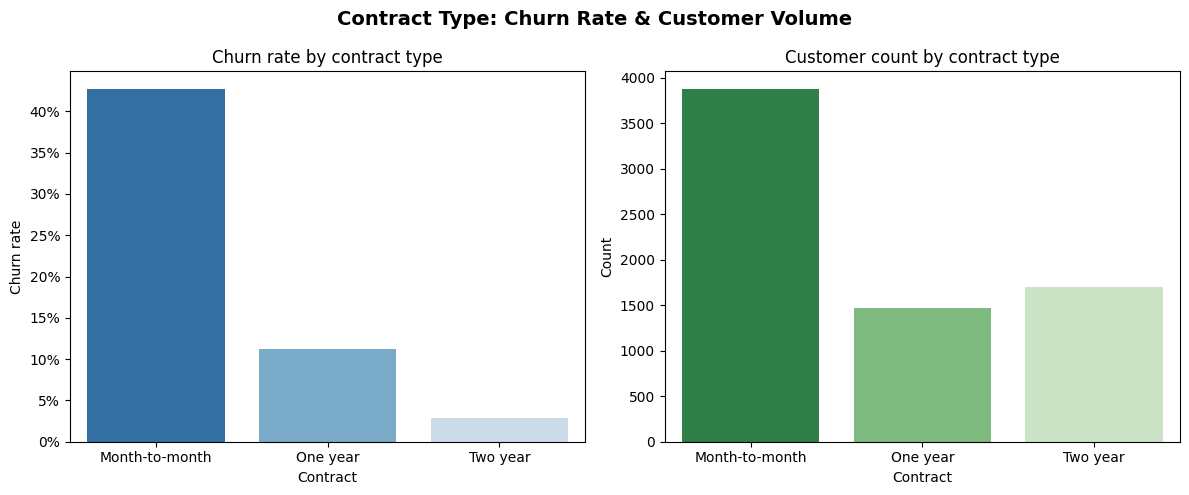

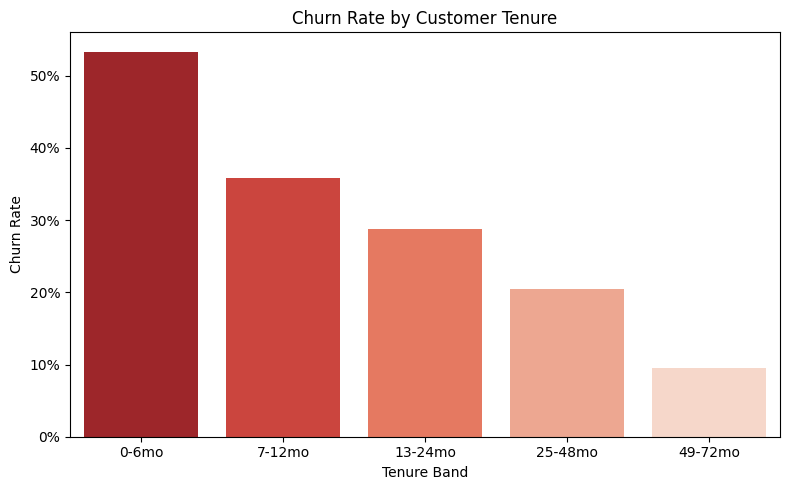

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_raw_data, clean_data

df = clean_data(load_raw_data("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"))
# --- Business Question 1 ---
# "Which contract type drives the most churn risk?"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Contract Type: Churn Rate & Customer Volume", fontsize=14, fontweight='bold')

churn_by_contract = df.groupby('Contract')['Churn_Binary'].agg(['mean','count']).reset_index()
churn_by_contract.columns = ['Contract','Churn_Rate','Count']

sns.barplot(
    data=churn_by_contract,
    x='Contract',
    y='Churn_Rate',
    hue='Contract',
    ax=axes[0],
    palette='Blues_r',
    legend=False
)
axes[0].set_title("Churn rate by contract type")
axes[0].set_ylabel("Churn rate")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

sns.barplot(
    data=churn_by_contract,
    x='Contract',
    y='Count',
    hue='Contract',
    ax=axes[1],
    palette='Greens_r',
    legend=False
)
axes[1].set_title("Customer count by contract type")

plt.tight_layout()
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/eda_contract_churn.png", dpi=150, bbox_inches='tight')

# Print the insight, not just the chart
for _, row in churn_by_contract.iterrows():
    print(f"{row['Contract']:25s} | Churn: {row['Churn_Rate']:.1%} | Customers: {row['Count']:,}")

# --- Business Question 2 ---
# "Is there a critical tenure window where churn is highest?"

df['tenure_band'] = pd.cut(df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6mo','7-12mo','13-24mo','25-48mo','49-72mo'])

tenure_churn = df.groupby('tenure_band', observed=True)['Churn_Binary'].mean()

print("\n=== Business Insight ===")

high_risk = churn_by_contract.sort_values("Churn_Rate", ascending=False).iloc[0]
low_risk = churn_by_contract.sort_values("Churn_Rate").iloc[0]

print(f"""
🔴 Highest churn risk:
{high_risk['Contract']} customers churn at {high_risk['Churn_Rate']:.1%}

🟢 Lowest churn risk:
{low_risk['Contract']} customers churn at {low_risk['Churn_Rate']:.1%}

💡 Key Insight:
Month-to-month customers are significantly more likely to churn compared to long-term contracts.

📈 Business Impact:
Since month-to-month customers form the largest segment, reducing churn in this group will have the biggest revenue impact.

🎯 Recommendation:
- Offer incentives to convert month-to-month users into yearly plans
- Improve onboarding experience for new users
""")

df['tenure_band'] = pd.cut(df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6mo','7-12mo','13-24mo','25-48mo','49-72mo']
)

tenure_churn = df.groupby('tenure_band', observed=True)['Churn_Binary'].mean()

plt.figure(figsize=(8,5))
sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn.values,
    hue=tenure_churn.index,
    palette='Reds_r',
    legend=False
)
plt.title("Churn Rate by Customer Tenure")
plt.ylabel("Churn Rate")
plt.xlabel("Tenure Band")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.savefig("reports/eda_tenure_churn.png", dpi=150)

print("\n=== Tenure Insight ===")
for band, rate in tenure_churn.items():
    print(f"{band:8s} | {rate:.1%}")

print("\nChurn rate by tenure band:")
for band, rate in tenure_churn.items():
    bar = '█' * int(rate * 30)
    print(f"  {band:8s} | {bar:30s} {rate:.1%}")